In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load your station-year dataset
df = pd.read_csv("Random_Forest_Modeling_Data.csv")
df.head()  # Quick check to ensure it loaded correctly

,station_id,year,station_name,latitude,longitude,elevation_m,baseline_summer_TMIN_C,baseline_summer_TMAX_C,TMIN_95_threshold_C,TMAX_95_threshold_C,valid_summer_TMIN_days,valid_summer_TMAX_days,warm_night_count,hot_day_count,summer_mean_TMIN_C,summer_mean_TMAX_C,percent_warm_nights,percent_hot_days,distance_to_coast_km
0,USC00040136,1970,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,120,120,2,11,15.192500,32.761667,1.666667,9.166667,30.623003
1,USC00040136,1972,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,119,119,5,13,15.198319,31.355462,4.201681,10.924370,30.623003
2,USC00040136,1974,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,113,113,0,5,14.569912,32.748673,0.000000,4.424779,30.623003
3,USC00040136,1975,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,116,111,0,4,13.402586,31.314414,0.000000,3.603604,30.623003
4,USC00040136,1976,"ALPINE, CA US",32.8358,-116.7774,516.6,15.773536,30.440052,22.2,37.2,118,117,1,12,14.350847,31.217094,0.847458,10.256410,30.623003


In [3]:
# Select only your numerical features
X = df[
    [
        "latitude",
        "longitude",
        "elevation_m",
        "valid_summer_TMIN_days",
        "distance_to_coast_km",
        "year",
    ]
]

# Define your target variable
y = df["percent_warm_nights"]

In [4]:
# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
# Initialize and fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model successfully trained!")

Random Forest model successfully trained!


In [6]:
# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
# original metrics
#Root Mean Squared Error (RMSE): 6.2059
#Mean Absolute Error (MAE): 3.2526
#R-squared (R2) Score: 0.9326

Root Mean Squared Error (RMSE): 3.5215
Mean Absolute Error (MAE): 2.3640
R-squared (R2) Score: 0.5276


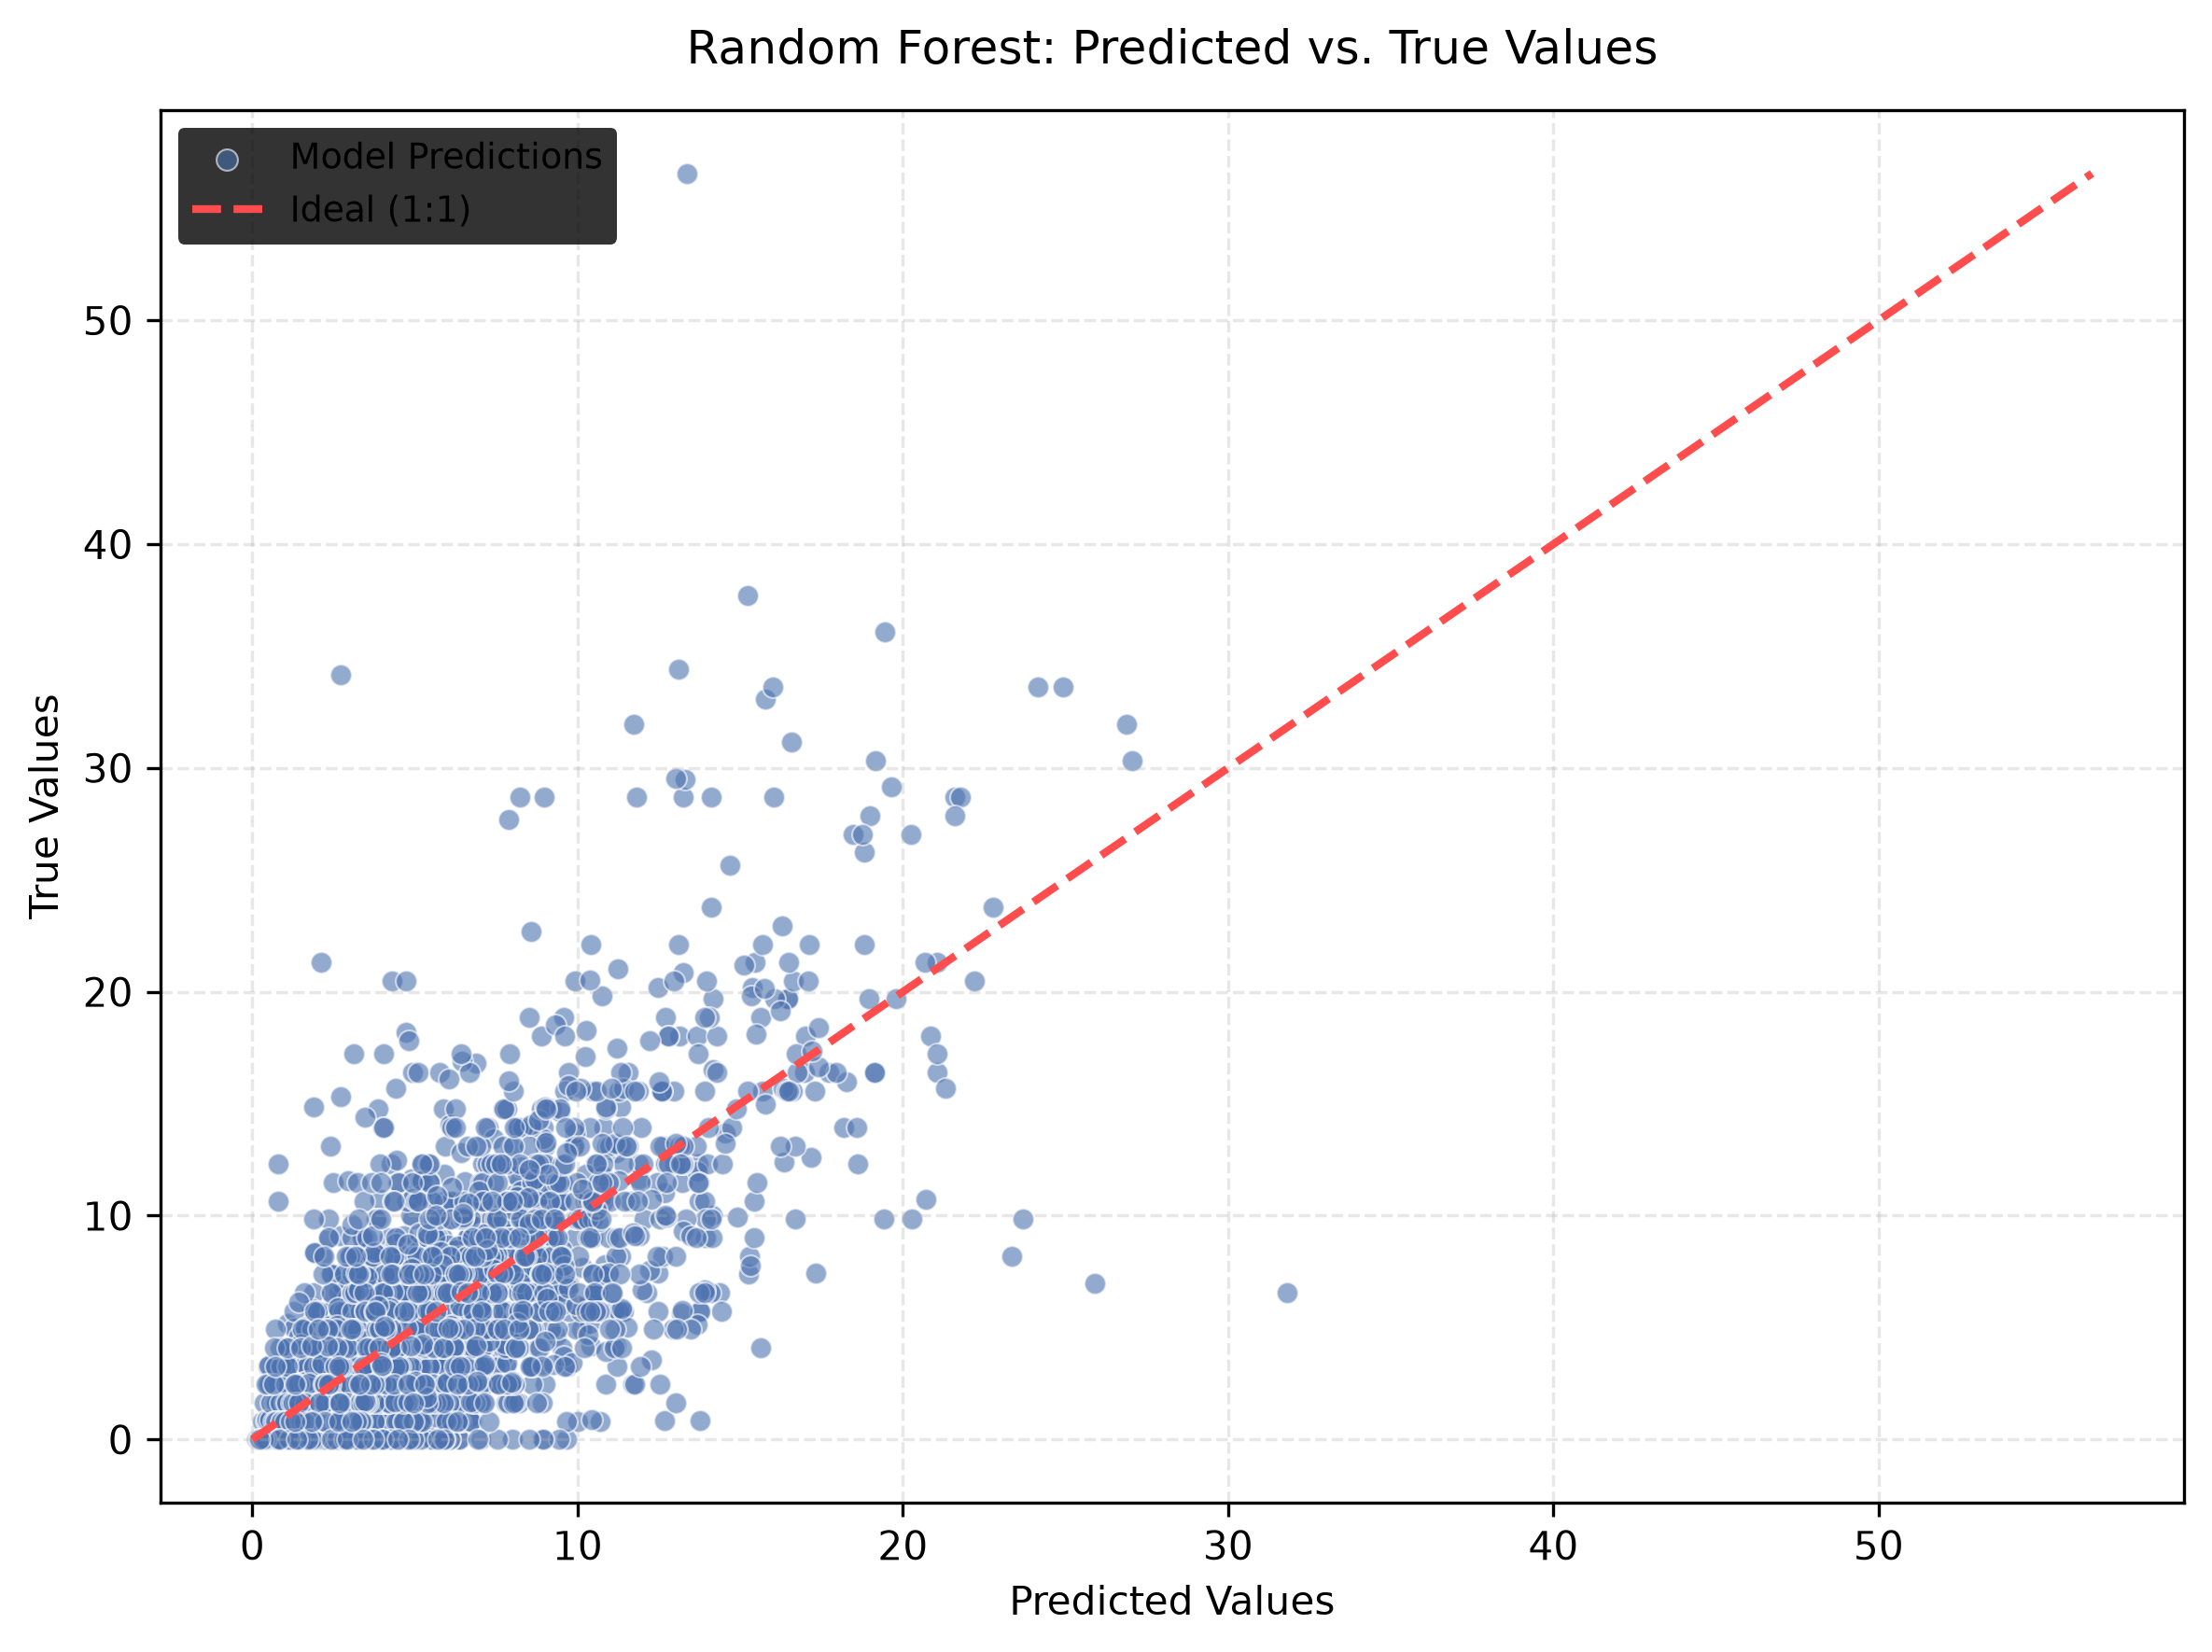

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Generate the scatterplot
plt.figure(figsize=(8, 6), dpi=300)

plt.scatter(
    y_pred,
    y_test,
    alpha=0.6,
    color='#4c72b0',
    edgecolor='white',
    linewidth=0.5,
    s=30,
    label='Model Predictions',
)

# Plot the ideal 45-degree reference line (y = x)
min_val = min(min(y_pred), min(y_test))
max_val = max(max(y_pred), max(y_test))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='#ff4d4d',
    linestyle='--',
    lw=2,
    label='Ideal (1:1)',
)

plt.title('Random Forest: Predicted vs. True Values', fontsize=12, pad=12)
plt.xlabel('Predicted Values', fontsize=10)
plt.ylabel('True Values', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='black', edgecolor='none', fontsize=9)
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_RF_Predicted_vs_True.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='black',
)
plt.show()